Projeler: Senin listenden 7 tane:

Yapay Sinir Ağları ile Görüntü Sınıflandırma (MLP) -yapmıştım tekrar yapmicam

CNN ile Rakam Görüntüsü Sınıflandırma (MNIST) -yapmıştım tekrar yapmicam

LSTM ile Film Yorumları Duygu Analizi

GAN ile Görüntü Oluşturma

Transformers ile Duygu Analizi (Text)

Autoencoder ile Moda Görüntüleri (Fashion-MNIST)

Transfer Learning ile İlaç Görüntüleri Sınıflandırma

LSTM ile Film Yorumları Duygu **Analizi**

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train size: 25000
Test size: 25000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 114ms/step - accuracy: 0.7754 - loss: 0.4529 - val_accuracy: 0.7612 - val_loss: 0.4825
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.8925 - loss: 0.2717 - val_accuracy: 0.8660 - val_loss: 0.3316
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 113ms/step - accuracy: 0.9279 - loss: 0.1864 - val_accuracy: 0.8754 - val_loss: 0.3287
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8672 - loss: 0.3566
Test Accuracy: 0.8671600222587585
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step
Tahmin: Negatif
Gerçek: Negatif
------
Tahmin: Pozitif
Gerçek: Pozitif
------
Tahmin: Pozitif
Gerçek: Pozitif
------
Tahmin: Negatif
Gerçek: Negatif
------
Tahmin: Pozitif
Gerçek: Pozitif
------


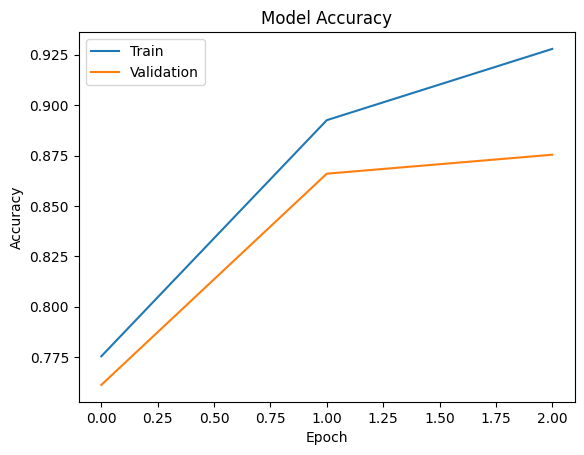

In [7]:
# =========================
# 📌 KÜTÜPHANELER
# =========================

import tensorflow as tf  # TensorFlow: Derin öğrenme modellerini oluşturmak ve eğitmek için kullanılan ana kütüphane
from tensorflow import keras  # Keras: TensorFlow'un yüksek seviyeli API'si, model kurmayı kolaylaştırır
from tensorflow.keras import layers  # layers: Dense, LSTM gibi katmanları kullanabilmek için import edilir
import numpy as np  # numpy: Sayısal işlemler ve array manipülasyonu için kullanılır
import matplotlib.pyplot as plt  # matplotlib: Grafik çizmek ve sonuçları görselleştirmek için kullanılır

# =========================
# 📌 VERİ SETİ (IMDB)
# =========================

max_features = 10000  # En sık kullanılan 10.000 kelimeyi al → modelin öğreneceği kelime sözlüğü boyutu
max_len = 200  # Her yorum maksimum 200 kelime olacak → uzunlukları eşitlemek için

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)
# IMDB veri setini yükler → metinler sayılara (token index) dönüştürülmüş şekilde gelir

print("Train size:", len(X_train))  # Eğitim veri sayısı (25.000)
print("Test size:", len(X_test))  # Test veri sayısı (25.000)

# =========================
# 📌 VERİYİ PAD ET (UZUNLUK EŞİTLEME)
# =========================

X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_len)
# Tüm yorumları 200 uzunluğa getirir → kısa olanlara 0 ekler, uzun olanları keser

X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_len)
# Test verisi için de aynı işlem yapılır → model aynı formatta veri bekler

# =========================
# 📌 MODEL OLUŞTUR (LSTM)
# =========================

model = keras.Sequential([  # Sequential model: Katmanlar sırayla ilerler

    layers.Embedding(input_dim=max_features, output_dim=128, input_length=max_len),
    # Embedding katmanı: Kelimeleri sayılardan yoğun vektörlere dönüştürür (word embedding)
    # input_dim → kaç farklı kelime var (10.000)
    # output_dim → her kelimeyi 128 boyutlu vektöre çevir
    # input_length → her yorumun uzunluğu (200)

    layers.LSTM(64),
    # LSTM katmanı: Metindeki sıralı bilgiyi öğrenir (cümle yapısı, bağlam vs.)
    # 64 → nöron sayısı (hafıza kapasitesi)

    layers.Dense(1, activation='sigmoid')
    # Çıkış katmanı: 0 veya 1 (negatif / pozitif)
    # sigmoid → 0-1 arasında olasılık üretir
])

# =========================
# 📌 MODEL DERLE
# =========================

model.compile(
    optimizer='adam',  # Adam optimizer: hızlı ve etkili öğrenme sağlar
    loss='binary_crossentropy',  # İkili sınıflandırma için uygun loss fonksiyonu
    metrics=['accuracy']  # Başarı ölçütü → accuracy
)

model.summary()  # Modelin katmanlarını ve parametrelerini gösterir

# =========================
# 📌 MODEL EĞİT
# =========================

history = model.fit(
    X_train, y_train,  # Eğitim verisi
    epochs=3,  # Eğitim sayısı (Colab için 3 yeterli, daha fazla da yapılabilir)
    batch_size=32,  # Her adımda 32 veri ile öğrenme
    validation_split=0.2  # %20 validation (model kendini test eder)
)

# =========================
# 📌 MODEL TEST
# =========================

loss, acc = model.evaluate(X_test, y_test)  # Test veri setinde performans ölçülür
print("Test Accuracy:", acc)  # Accuracy yazdırılır

# =========================
# 📌 TAHMİN
# =========================

predictions = model.predict(X_test)  # Test verisi için tahmin yapar

for i in range(5):  # İlk 5 yorum için sonuç göster
    print("Tahmin:", "Pozitif" if predictions[i] > 0.5 else "Negatif")  # 0.5 üstü pozitif
    print("Gerçek:", "Pozitif" if y_test[i] == 1 else "Negatif")  # Gerçek etiket
    print("------")

# =========================
# 📌 GRAFİK (EĞİTİM PERFORMANSI)
# =========================

plt.plot(history.history['accuracy'])  # Eğitim accuracy grafiği
plt.plot(history.history['val_accuracy'])  # Validation accuracy grafiği
plt.title("Model Accuracy")  # Başlık
plt.xlabel("Epoch")  # X ekseni
plt.ylabel("Accuracy")  # Y ekseni
plt.legend(["Train", "Validation"])  # Açıklama
plt.show()  # Grafiği göster